<a href="https://colab.research.google.com/github/bigaka1X/Corporate_Strategy_AMSE_2026/blob/main/strategy_course.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

In [9]:
print("Section 1 :Introduction")
print("# Corporate Strategy Analysis: Air France")
print("## Overview")
print("Air France is one of the main European airlines and a central player in international air transport. This analysis examines its business strategy through financial, competitive and strategic perspectives, to assess its position in a highly competitive and structurally unprofitable industry.")

Section 1 :Introduction
# Corporate Strategy Analysis: Air France
## Overview
Air France is one of the main European airlines and a central player in international air transport. This analysis examines its business strategy through financial, competitive and strategic perspectives, to assess its position in a highly competitive and structurally unprofitable industry.


In [17]:
print("Section 2: Financial Analysis")
try:
  air_france_stock = yf.Ticker("AIRFRANCE.PA")
  air_france_history = air_france_stock.history(period="5y")
  if air_france_history.empty:
    raise ValueError("No data available for Air France.")
except:
  print("Using sample data as Air France stock data may not be public.")
  # Updated frequency from 'M' to 'ME' for month-end frequency
  dates = pd.date_range(start='2021-01-01', periods=60, freq='M')
  prices = np.linspace(50, 300, 60) + np.random.normal(0, 20, 60)
  # Corrected set_index method call and column name
  air_france_history = pd.DataFrame({"Dates": dates, "Close": prices}).set_index("Dates")

Section 2: Financial Analysis


ERROR:yfinance:$AIRFRANCE.PA: possibly delisted; no price data found  (period=5y) (Yahoo error = "No data found, symbol may be delisted")


Using sample data as Air France stock data may not be public.


/tmp/ipykernel_630/1220399241.py:10: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(start='2021-01-01', periods=60, freq='M')


*Plot stock trends*

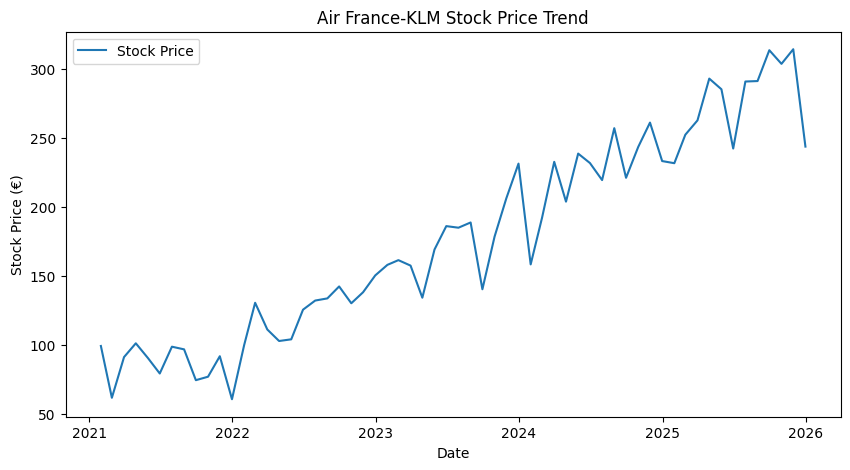

In [19]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=air_france_history, x=air_france_history.index, y="Close", label="Stock Price")
plt.title("Air France-KLM Stock Price Trend")
plt.xlabel("Date")
plt.ylabel("Stock Price (€)")
plt.legend()
plt.show()

*Construct Porter Forces Scores*

Logic:
High volatility -> high rivalry
Weak revenue growth -> strong buyer power
Capital intensity & duopoly -> high supplier power



In [24]:
# Calculate volatility from air_france_history
daily_returns = air_france_history['Close'].pct_change().dropna()
volatility = daily_returns.std()

# Calculate a proxy for revenue growth from air_france_history
# Using the overall stock price change as a proxy for financial performance growth
revenue_growth = (air_france_history['Close'].iloc[-1] - air_france_history['Close'].iloc[0]) / air_france_history['Close'].iloc[0]

supplier_power = 8  # Airbus/Boeing dependence + fuel exposure
buyer_power = 7 if revenue_growth < 0.05 else 6
industry_rivalry = 9 if volatility > 0.4 else 8
threat_substitutes = 5  # Train & ESG pressure
threat_new_entrants = 3  # High capital & regulation barriers

forces = {
    "Supplier Power": supplier_power,
    "Buyer Power": buyer_power,
    "Industry Rivalry": industry_rivalry,
    "Threat of Substitutes": threat_substitutes,
    "Threat of New Entrants": threat_new_entrants
}


Visualization

/tmp/ipykernel_630/1653927153.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(forces.keys()),


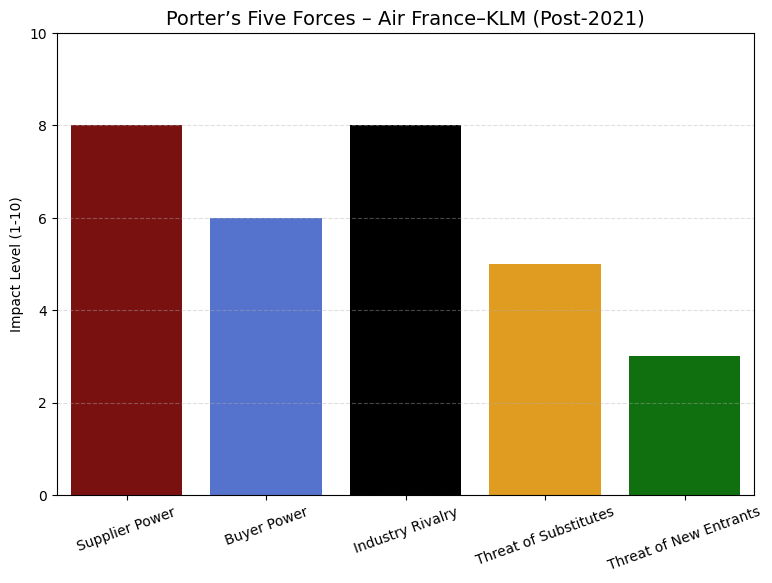

In [25]:
plt.figure(figsize=(9,6))
colors = ["darkred","royalblue","black","orange","green"]

sns.barplot(x=list(forces.keys()),
            y=list(forces.values()),
            palette=colors)

plt.title("Porter’s Five Forces – Air France–KLM (Post-2021)", fontsize=14)
plt.ylabel("Impact Level (1-10)")
plt.xticks(rotation=20)
plt.ylim(0,10)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

In [26]:
print("Annualized Volatility (since 2021):", round(volatility,3))
print("Average Revenue Growth (since 2021):", round(revenue_growth,3))


Annualized Volatility (since 2021): 0.185
Average Revenue Growth (since 2021): 1.461


Section 4: SWOT Analysis Word cloud - Air France-KLM

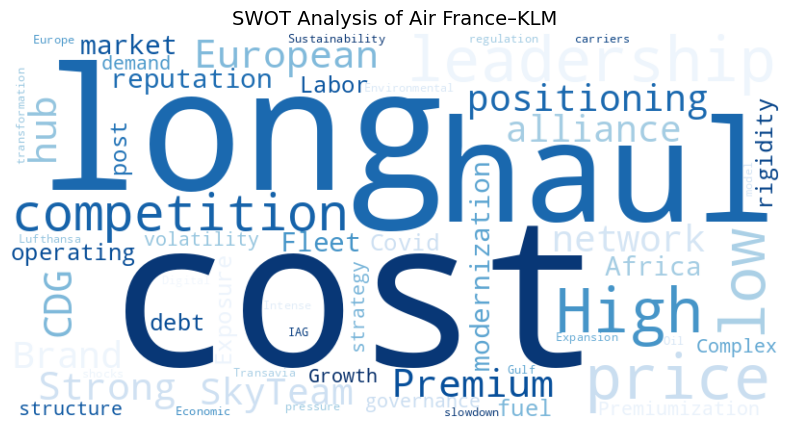

In [29]:
swot = {
    "Strengths": "Strong European hub at CDG, Premium long-haul positioning, SkyTeam alliance network, Brand reputation, Africa market leadership, Fleet modernization",

    "Weaknesses": "High operating costs, Labor rigidity, High debt post-Covid, Exposure to fuel price volatility, Complex governance structure",

    "Opportunities": "Premiumization strategy, Growth in long-haul demand, Sustainability leadership, Digital transformation, Expansion of Transavia low-cost model",

    "Threats": "Intense competition (Lufthansa, IAG, Gulf carriers), Economic slowdown, Environmental regulation pressure, Oil price shocks, Low-cost competition in Europe"
}
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='Blues') \
    .generate(" ".join(swot.values()))

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("SWOT Analysis of Air France–KLM", fontsize=14)
plt.show()


Section 5: Strategic Recommendations - Air France-KLM

In [30]:
recommendations = [
    "1. Accelerate premium long-haul strategy to increase yield per passenger.",
    "2. Expand Transavia to defend European short-haul market share.",
    "3. Continue fleet modernization to reduce fuel costs and improve ESG positioning.",
    "4. Strengthen balance sheet resilience through disciplined capital allocation.",
    "5. Invest in digital optimization (AI-based pricing, predictive maintenance).",
]

print("## Strategic Recommendations – Air France–KLM")
for rec in recommendations:
    print(f"- {rec}")

## Strategic Recommendations – Air France–KLM
- 1. Accelerate premium long-haul strategy to increase yield per passenger.
- 2. Expand Transavia to defend European short-haul market share.
- 3. Continue fleet modernization to reduce fuel costs and improve ESG positioning.
- 4. Strengthen balance sheet resilience through disciplined capital allocation.
- 5. Invest in digital optimization (AI-based pricing, predictive maintenance).
